# 07 · Smoothing noisy signals

**Problem.** A detector records two overlapping peaks (e.g. a chromatogram or a spectrum) with
noise. We want the peak positions and heights - which requires smoothing, and often derivatives.
Smoothing always trades **noise reduction** against **distortion** (peaks get lower and wider).

**What you will learn**

- compare moving-average, Savitzky-Golay and LOWESS smoothing
- derive Savitzky-Golay weights from local least squares
- choose a window size by balancing noise against distortion
- locate peaks from smoothed derivatives

**Before you start:** notebook 00; least squares (notebook 08 is helpful)  ·  **Time:** about 45 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import smoothing

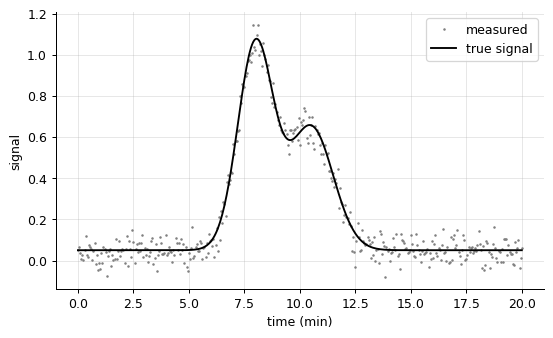

In [2]:
x = np.linspace(0, 20, 401); dx = x[1] - x[0]
def peak(x, h, c, w): return h*np.exp(-0.5*((x - c)/w)**2)
true = peak(x, 1.0, 8.0, 0.8) + peak(x, 0.6, 10.5, 1.0) + 0.05
rng = np.random.default_rng(7)
y = true + rng.normal(0, 0.05, x.size)
plt.plot(x, y, ".", ms=2, color="gray", label="measured"); plt.plot(x, true, "k", label="true signal")
plt.xlabel("time (min)"); plt.ylabel("signal"); plt.legend(); plt.show()

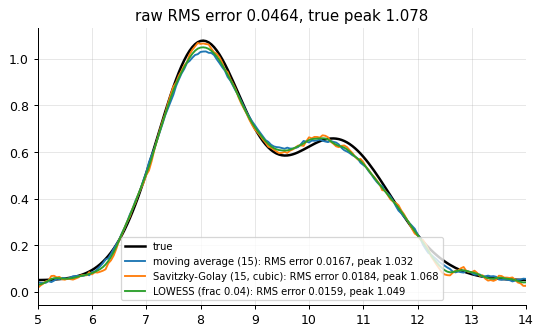

In [3]:
sm = {"moving average (15)": smoothing.moving_average(y, 15),
      "Savitzky-Golay (15, cubic)": smoothing.savitzky_golay(y, 7, 3),
      "LOWESS (frac 0.04)": smoothing.lowess(x, y, 0.04)}
fig, ax = plt.subplots()
ax.plot(x, true, "k", lw=2, label="true")
for k, v in sm.items():
    rms = np.sqrt(np.mean((v - true)**2))
    ax.plot(x, v, label=f"{k}: RMS error {rms:.4f}, peak {v.max():.3f}")
ax.set_xlim(5, 14); ax.legend(fontsize=8); ax.set_title(f"raw RMS error {np.sqrt(np.mean((y-true)**2)):.4f}, true peak {true.max():.3f}")
plt.show()

## Inside the algorithm: where Savitzky-Golay weights come from
Fit a polynomial by least squares to the $2m + 1$ points of a window and evaluate it at the centre.
Because the fit is linear in the data, the result is a *fixed weighted average* of the window - a row of
the pseudo-inverse of the Vandermonde matrix. For 5 points and a quadratic, this gives the classic
weights $(-3, 12, 17, 12, -3)/35$:

In [4]:
m, order = 2, 2
t_win = np.arange(-m, m + 1)
V = np.vander(t_win, order + 1, increasing=True)    # columns: 1, t, t^2
P = np.linalg.pinv(V)
print("smoothing weights x 35:", np.round(P[0] * 35, 6) + 0.0)          # + 0.0 turns -0.0 into 0.0
print("first-derivative weights x 10:", np.round(P[1] * 10, 6) + 0.0)

smoothing weights x 35: [-3. 12. 17. 12. -3.]
first-derivative weights x 10: [-2. -1.  0.  1.  2.]


Smoothing is then a convolution with these weights, and the derivative uses the second row - exactly
what `smoothing.savitzky_golay` does:

In [5]:
show_source(smoothing.savitzky_golay)

def savitzky_golay(y, half_window: int = 5, order: int = 2, deriv: int = 0, dx: float = 1.0) -> np.ndarray:
    """Savitzky-Golay filter for EQUALLY spaced data: fit a polynomial of ``order`` by least
    squares in each window of 2*half_window + 1 points and take its value (deriv=0) or its
    derivative (deriv=1, 2). Edges use the fit of the first/last full window."""
    y = np.asarray(y, float)
    m = half_window
    if 2 * m + 1 > y.size or order >= 2 * m + 1:
        raise ValueError("Window too large for the data, or order too high for the window.")
    t = np.arange(-m, m + 1)
    V = np.vander(t, order + 1, increasing=True)
    C = np.linalg.pinv(V)  # rows give polynomial coefficients from window values
    fact = np.prod(np.arange(1, deriv + 1)) if deriv else 1
    out = np.empty_like(y)
    coef_row = C[deriv] * fact / dx**deriv
    out[m:-m] = np.convolve(y, coef_row[::-1], mode="valid")
    poly = np.polynomial.Polynomial
    n = y.size
    left = poly(C @ y[: 2 * m + 1])
    right = poly(C @ y[-(2 * m + 1):])
    if deriv:
        left, right = left.deriv(deriv), right.deriv(deriv)
    for i in range(m):  # edges: evaluate the end-window polynomial away from its centre
        out[i] = left(i - m) / dx**deriv
        out[n - m + i] = right(i + 1) / dx**deriv
    return out

The moving average flattens the peak most: it fits a *constant* in each window. Savitzky-Golay fits
a *polynomial* in each window, which follows curvature and preserves the peak height much better - but
for the same window it removes less noise, so its overall RMS error is not the smallest. No filter wins
on every criterion: choose by what matters for your analysis (peak heights, positions or noise level).

## The window-size trade-off

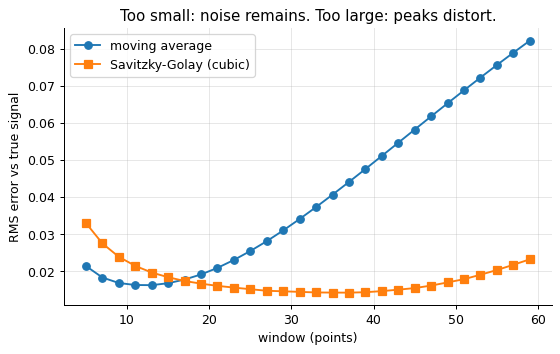

In [6]:
halves = np.arange(2, 30)
rms_ma = [np.sqrt(np.mean((smoothing.moving_average(y, 2*m+1) - true)**2)) for m in halves]
rms_sg = [np.sqrt(np.mean((smoothing.savitzky_golay(y, m, 3) - true)**2)) for m in halves]
plt.plot(2*halves+1, rms_ma, "o-", label="moving average"); plt.plot(2*halves+1, rms_sg, "s-", label="Savitzky-Golay (cubic)")
plt.xlabel("window (points)"); plt.ylabel("RMS error vs true signal"); plt.legend()
plt.title("Too small: noise remains. Too large: peaks distort."); plt.show()

## Derivatives of smoothed data locate peaks
A maximum is where the first derivative crosses zero going downwards. Savitzky-Golay gives smoothed
derivatives directly (`deriv=1`).

downward zero crossings: raw derivative 93, smoothed 26
peaks (signal above 0.3): [ 8.04 10.2 ]   - true centres 8.0 and 10.5


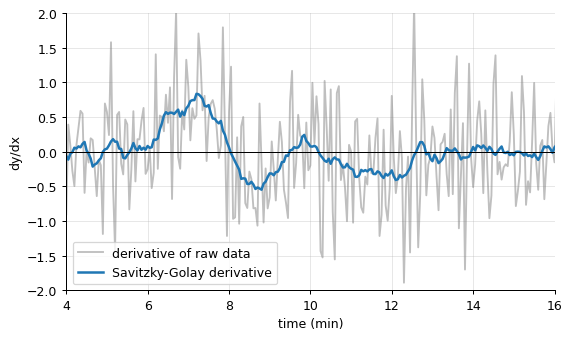

In [7]:
d1 = smoothing.savitzky_golay(y, 10, 3, deriv=1, dx=dx)
d1_raw = np.gradient(y, dx)
def downward_crossings(d):
    return np.where((d[:-1] > 0) & (d[1:] <= 0))[0]
smooth = smoothing.savitzky_golay(y, 10, 3)
print(f"downward zero crossings: raw derivative {downward_crossings(d1_raw).size}, smoothed {downward_crossings(d1).size}")
real = [i for i in downward_crossings(d1) if smooth[i] > 0.3]      # keep only crossings on a real peak
peaks = [x[i] - d1[i]*(x[i+1]-x[i])/(d1[i+1]-d1[i]) for i in real]
print("peaks (signal above 0.3):", np.round(peaks, 2), "  - true centres 8.0 and 10.5")
fig, ax = plt.subplots()
ax.plot(x, d1_raw, color="gray", alpha=0.5, label="derivative of raw data")
ax.plot(x, d1, lw=2, label="Savitzky-Golay derivative"); ax.axhline(0, color="k", lw=0.8)
ax.set(xlim=(4, 16), ylim=(-2, 2), xlabel="time (min)", ylabel="dy/dx"); ax.legend(); plt.show()

Smoothing cuts the false zero crossings drastically, but the flat noisy baseline still produces some:
a **minimum peak height** is needed as well, which is what practical peak-picking software does.
The second peak's maximum appears below 10.5 because it sits on the tail of the first peak - the
maximum of a *sum* of peaks is not the centre of either (curve fitting, notebook 09, separates them).

## Exercises
1. Add a single spike (an electrical glitch) to the signal. Compare `lowess` with and without
   `robust_iters=2`.
2. Use the second derivative (`deriv=2`) to detect the shoulder of the smaller peak. Why is the
   second derivative even more sensitive to the window size?
3. Show that a Savitzky-Golay filter of order 2 with a 5-point window reproduces any quadratic
   exactly. Why does that make it suitable for smooth physical signals?
4. **Implement it yourself:** write `exponential_smoothing(y, a)` with $s_i = a\,y_i + (1 - a)\,s_{i-1}$, the filter used in many real-time instruments. Apply it to the peaks. Why does it shift them to later times, unlike the centred filters?